# XGBoost Encoding Benchmark – pp_bi

Benchmarks 4 categorical encoding strategies on the pp_bi (Bodily Injury pure premium) target.

| Step | Description |
|------|-------------|
| 0 | Set DEBUG flag – `1` = 10K rows, `0` = full data |
| 1 | (First run only) Generate `config/level_mapping_reference.csv` |
| 2 | Load train / test data |
| 3 | Run 4 encoding experiments + train XGBoost |
| 4 | Compare results |
| 5 | Save all models & artifacts |

**Files used:**
- `code/create_level_mapping.py` – Program 1: builds the mapping CSV  
- `code/encoding_strategies.py` – 4 encoding functions  
- `code/model_training.py`       – Train, evaluate, save, compare  

**Outputs:**
- `models/pp_bi_type{1-4}_*/` – Model + encoders + predictions  
- `results/encoding_benchmark_summary.csv` – Comparison table

---
## 0 · Setup & DEBUG flag

In [2]:
import os, sys

PROJECT_ROOT = os.path.abspath(os.getcwd())
sys.path.insert(0, os.path.join(PROJECT_ROOT, "code"))

# ── Toggle this flag ─────────────────────────────────────────────────────────
DEBUG = 1    # 1 = 10K train rows (fast test)  |  0 = full dataset
# ─────────────────────────────────────────────────────────────────────────────

print(f"Project root : {PROJECT_ROOT}")
print(f"DEBUG        : {DEBUG}  ({'10K rows' if DEBUG else 'FULL DATA'})")

Project root : /Users/Mach/dev/aps/code/26CF_Dmod_v1/experiment_levels
DEBUG        : 1  (10K rows)


---
## 1 · Generate level mapping CSV (run once)

Skip this cell if `config/level_mapping_reference.csv` already exists.

In [3]:
import importlib, create_level_mapping as clm

MAPPING_CSV = os.path.join(PROJECT_ROOT, "config", "level_mapping_reference.csv")

if not os.path.exists(MAPPING_CSV):
    print("Mapping CSV not found – generating now ...")
    # Temporarily override the DEBUG flag inside the module
    clm.DEBUG = DEBUG
    clm.main()
else:
    print(f"✅ Mapping CSV already exists:\n   {MAPPING_CSV}")
    print("   Delete it and re-run this cell to regenerate.")

✅ Mapping CSV already exists:
   /Users/Mach/dev/aps/code/26CF_Dmod_v1/experiment_levels/config/level_mapping_reference.csv
   Delete it and re-run this cell to regenerate.


---
## 2 · Load train and test data

In [4]:
from encoding_strategies import load_train_test, get_y

train_raw, test_raw = load_train_test(debug=bool(DEBUG))

y_train = get_y(train_raw)
y_test  = get_y(test_raw)

print(f"y_train : mean={y_train.mean():.4f}  std={y_train.std():.4f}")
print(f"y_test  : mean={y_test.mean():.4f}  std={y_test.std():.4f}")

[DEBUG] Loading train ...
[DEBUG] Loading test  ...
  Train: 9,503 rows  |  Test: 1,907 rows
  [Ceiling] Applied 100,000 cap to 'pp_bi': 4 rows capped (0.04%)
  [Ceiling] Applied 100,000 cap to 'pp_bi': 1 rows capped (0.05%)
y_train : mean=152.3102  std=3155.5378
y_test  : mean=139.8947  std=3005.9407


---
## 2.5 · Quick Iterative Experiment

**Iterative tuning workflow:**
1. Edit `config.json` (change `learning_rate`, `n_estimators`, etc.)
2. Run this cell
3. See lift chart + metrics immediately
4. Repeat — no kernel restart needed

Set `ITER_ENC` to choose which encoding to benchmark:
- `1` = Type 1 Ordinal
- `2` = Type 2 Binary
- `3` = Type 3 Actuarial
- `4` = Type 4 Custom

  XGBoost config loaded: objective=reg:tweedie, n_estimators=5000, lr=0.05
  [reload] objective=reg:tweedie, n_estimators=5000, lr=0.05, tweedie_vp=1.5
  [Type 1] Ordinal encoding ...
     Features: 15412  (numeric ordinal: 341, OHE string: 15071)

  Training type1_ordinal_run_v1 ...
    X_train shape : (9503, 15412)
    X_test  shape : (1907, 15412)
    base_score    : 152.3102  (mean of y_train)
    ✅ Done  |  RMSE=1400.8321  MAE=50.3323  R²=0.7827  Time=321.1s
  💾 Lift chart saved: /Users/Mach/dev/aps/code/26CF_Dmod_v1/experiment_levels/results/lift_charts/lift_type1_ordinal_run_v1.png


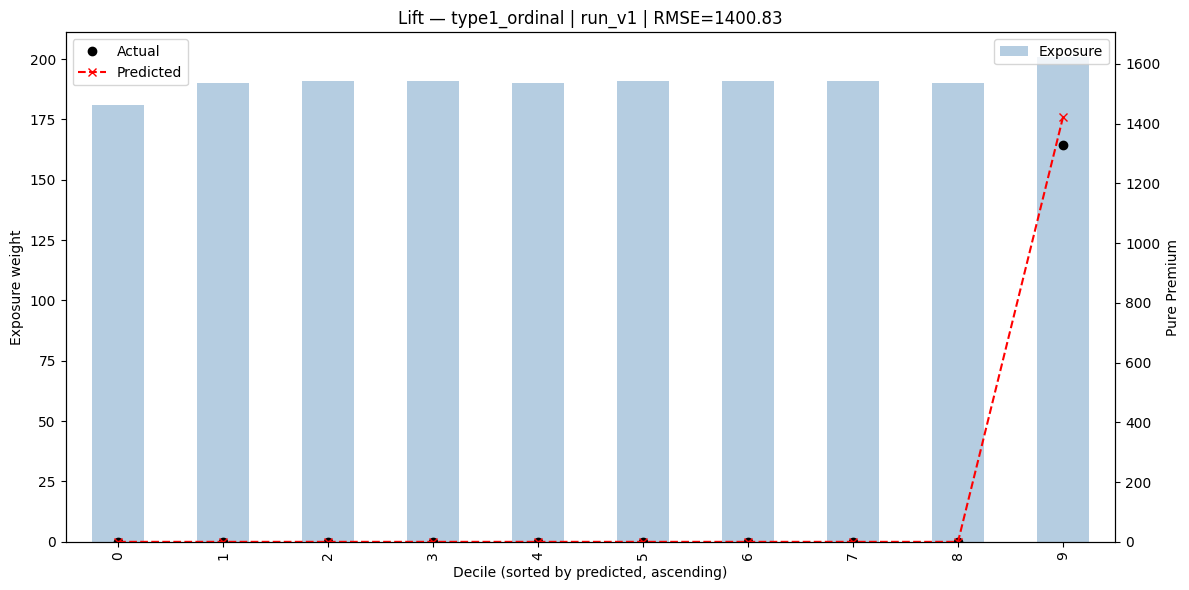

  RMSE : 1400.8321
  MAE  : 50.3323
  R²   : 0.7827


In [5]:
# ── Edit these two lines, then run ───────────────────────────────────────────
ITER_ENC  = 1          # Encoding type: 1 / 2 / 3 / 4
ITER_NAME = 'run_v1'   # Label for this run (shows in lift chart title)
# ─────────────────────────────────────────────────────────────────────────────

import model_training as _mt
_mt.reload_config()   # Re-read config.json — no kernel restart needed

from encoding_strategies import encode_type1_ordinal, encode_type2_binary
from encoding_strategies import encode_type3_actuarial, encode_type4_custom
from model_training import train_and_evaluate
from visualization import lift_chart

_enc_map = {
    1: lambda: encode_type1_ordinal(train_raw, test_raw) + (None,),
    2: lambda: encode_type2_binary(train_raw,  test_raw) + (None,),
    3: lambda: encode_type3_actuarial(train_raw, test_raw),
    4: lambda: encode_type4_custom(train_raw, test_raw) + (None,),
}
_enc_names = {1:'type1_ordinal', 2:'type2_binary', 3:'type3_actuarial', 4:'type4_custom'}

if ITER_ENC not in _enc_map:
    raise ValueError(f'ITER_ENC must be 1/2/3/4, got {ITER_ENC}')

_out = _enc_map[ITER_ENC]()
_X_tr, _X_te, _feats = _out[0], _out[1], _out[2]

_result = train_and_evaluate(
    experiment_name = f"{_enc_names[ITER_ENC]}_{ITER_NAME}",
    X_train=_X_tr, y_train=y_train,
    X_test =_X_te, y_test =y_test,
    feature_names=_feats,
)

lift_chart(_result, test_df=test_raw, bins=10, print_table=False,
           title=f'Lift — {_enc_names[ITER_ENC]} | {ITER_NAME} | RMSE={_result["metrics"]["rmse"]:.2f}')

print(f'  RMSE : {_result["metrics"]["rmse"]:.4f}')
print(f'  MAE  : {_result["metrics"]["mae"]:.4f}')
print(f'  R²   : {_result["metrics"]["r2"]:.4f}')

---
## 3 · Experiment 1 – Ordinal encoding (Type 1)

In [6]:
from encoding_strategies import encode_type1_ordinal
from model_training import train_and_evaluate, save_experiment

X_tr1, X_te1, feats1 = encode_type1_ordinal(train_raw, test_raw)

result1 = train_and_evaluate(
    experiment_name = "type1_ordinal",
    X_train=X_tr1, y_train=y_train,
    X_test=X_te1,  y_test=y_test,
    feature_names=feats1,
)
save_experiment(result1)

  [Type 1] Ordinal encoding ...
     Features: 15412  (numeric ordinal: 341, OHE string: 15071)

  Training type1_ordinal ...
    X_train shape : (9503, 15412)
    X_test  shape : (1907, 15412)
    base_score    : 152.3102  (mean of y_train)
    ✅ Done  |  RMSE=1400.8321  MAE=50.3323  R²=0.7827  Time=321.7s
    💾 Saved to: /Users/Mach/dev/aps/code/26CF_Dmod_v1/experiment_levels/models/pp_bi_type1_ordinal/


'/Users/Mach/dev/aps/code/26CF_Dmod_v1/experiment_levels/models/pp_bi_type1_ordinal'

---
## 4 · Experiment 2 – Binary encoding (Type 2)

In [7]:
from encoding_strategies import encode_type2_binary

X_tr2, X_te2, feats2 = encode_type2_binary(train_raw, test_raw)

result2 = train_and_evaluate(
    experiment_name = "type2_binary",
    X_train=X_tr2, y_train=y_train,
    X_test=X_te2,  y_test=y_test,
    feature_names=feats2,
)
save_experiment(result2)

  [Type 2] Binary encoding ...


/Users/Mach/dev/aps/code/26CF_Dmod_v1/experiment_levels/code/encoding_strategies.py:250: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_tr[col] = train[col].astype("float32")
/Users/Mach/dev/aps/code/26CF_Dmod_v1/experiment_levels/code/encoding_strategies.py:251: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_te[col] = test[col].astype("float32")
/Users/Mach/dev/aps/code/26CF_Dmod_v1/experiment_levels/code/encoding_strategies.py:250: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `fr

     Features: 15412  (0-5 binary: 165, other numeric: 176, OHE string: 15071)

  Training type2_binary ...
    X_train shape : (9503, 15412)
    X_test  shape : (1907, 15412)
    base_score    : 152.3102  (mean of y_train)
    ✅ Done  |  RMSE=1537.9817  MAE=56.6317  R²=0.7381  Time=318.7s
    💾 Saved to: /Users/Mach/dev/aps/code/26CF_Dmod_v1/experiment_levels/models/pp_bi_type2_binary/


'/Users/Mach/dev/aps/code/26CF_Dmod_v1/experiment_levels/models/pp_bi_type2_binary'

---
## 5 · Experiment 3 – Actuarial encoding (Type 3, DH-Liab / pp_bi)

In [8]:
from encoding_strategies import encode_type3_actuarial

X_tr3, X_te3, feats3, encoders3 = encode_type3_actuarial(train_raw, test_raw)

result3 = train_and_evaluate(
    experiment_name = "type3_actuarial",
    X_train=X_tr3, y_train=y_train,
    X_test=X_te3,  y_test=y_test,
    feature_names=feats3,
)
save_experiment(result3, encoders=encoders3)

  [Type 3] Actuarial encoding ...
     Features: 528

  Training type3_actuarial ...
    X_train shape : (9503, 528)
    X_test  shape : (1907, 528)
    base_score    : 152.3102  (mean of y_train)
    ✅ Done  |  RMSE=1318.9135  MAE=49.6838  R²=0.8074  Time=21.1s
    💾 Saved to: /Users/Mach/dev/aps/code/26CF_Dmod_v1/experiment_levels/models/pp_bi_type3_actuarial/


'/Users/Mach/dev/aps/code/26CF_Dmod_v1/experiment_levels/models/pp_bi_type3_actuarial'

---
## 6 · Experiment 4 – Custom encoding (Type 4)

Reads `type_4_custom` column from `config/level_mapping_reference.csv`.  
Currently falls back to Type 1 until the column is populated.

In [9]:
# from encoding_strategies import encode_type4_custom

# X_tr4, X_te4, feats4 = encode_type4_custom(train_raw, test_raw)

# result4 = train_and_evaluate(
#     experiment_name = "type4_custom",
#     X_train=X_tr4, y_train=y_train,
#     X_test=X_te4,  y_test=y_test,
#     feature_names=feats4,
# )
# save_experiment(result4)

---
## 7 · Compare all experiments

In [10]:
from model_training import compare_results

# Add result4 here if you ran Experiment 4
all_results = [result1, result2, result3]
summary_df  = compare_results(all_results)

display(summary_df)


  ENCODING BENCHMARK SUMMARY  (sorted by RMSE ↑ best)
                        rmse        mae        r2  training_time_sec  n_train  n_test  n_features
experiment                                                                                       
type3_actuarial  1318.913473  49.683784  0.807381               21.1     9503    1907         528
type1_ordinal    1400.832119  50.332336  0.782710              321.7     9503    1907       15412
type2_binary     1537.981713  56.631668  0.738080              318.7     9503    1907       15412

  🏆 Best strategy: type3_actuarial  (RMSE=1318.9135)

  📄 Summary saved: /Users/Mach/dev/aps/code/26CF_Dmod_v1/experiment_levels/results/encoding_benchmark_summary.csv


,rmse,mae,r2,training_time_sec,n_train,n_test,n_features
experiment,,,,,,,
type3_actuarial,1318.913473,49.683784,0.807381,21.1,9503,1907,528
type1_ordinal,1400.832119,50.332336,0.782710,321.7,9503,1907,15412
type2_binary,1537.981713,56.631668,0.738080,318.7,9503,1907,15412


---
## 8 · Lift Charts – Individual Models

  💾 Lift chart saved: /Users/Mach/dev/aps/code/26CF_Dmod_v1/experiment_levels/results/lift_charts/lift_type1_ordinal.png


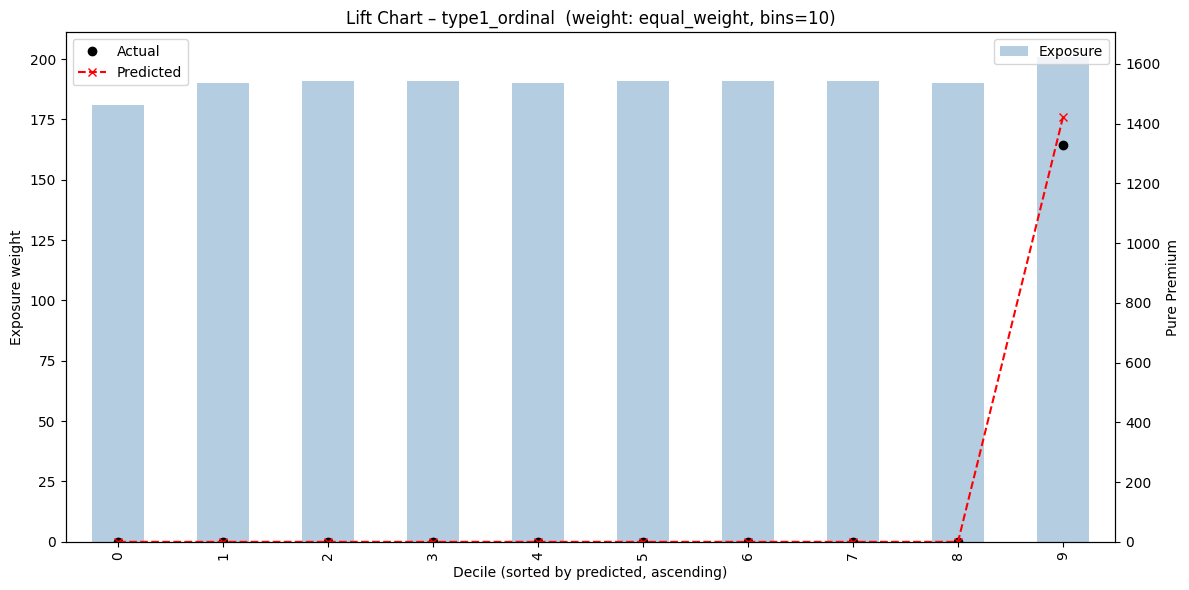

 decile  weight        act         pred
    1.0   181.0    0.00000 3.818293e-08
    2.0   190.0    0.00000 3.818293e-08
    3.0   191.0    0.00000 3.818293e-08
    4.0   191.0    0.00000 3.818293e-08
    5.0   190.0    0.00000 3.818293e-08
    6.0   191.0    0.00000 3.818293e-08
    7.0   191.0    0.00000 3.983190e-08
    8.0   191.0    0.00000 4.496272e-08
    9.0   190.0    0.00000 4.890988e-08
   10.0   201.0 1327.25919 1.421480e+03
  💾 Lift chart saved: /Users/Mach/dev/aps/code/26CF_Dmod_v1/experiment_levels/results/lift_charts/lift_type2_binary.png


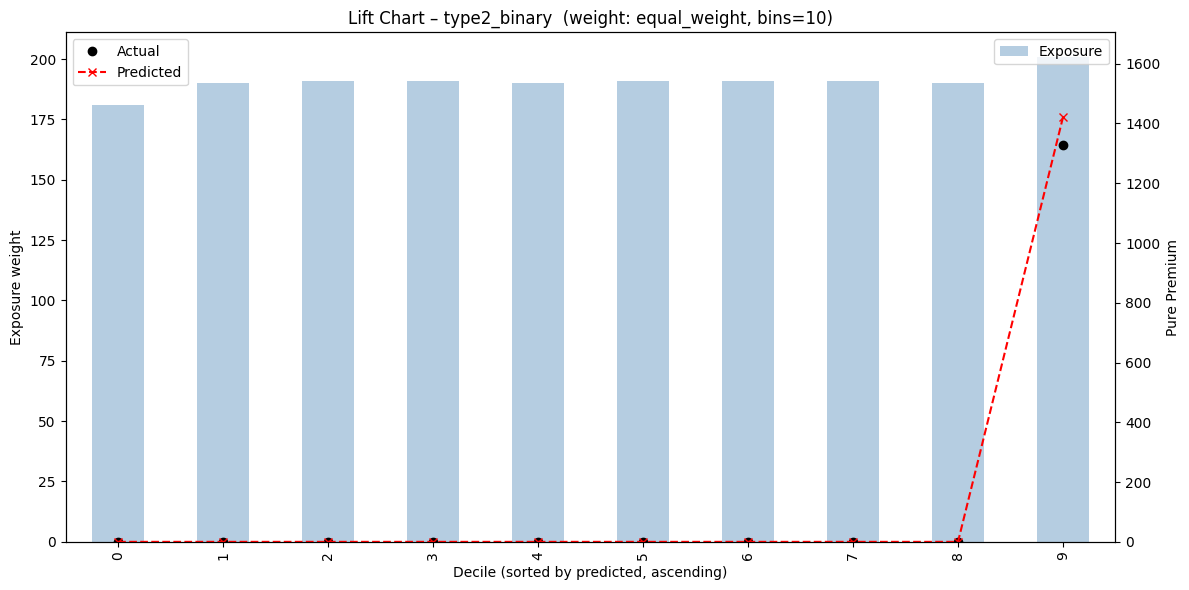

 decile  weight        act         pred
    1.0   181.0    0.00000 3.816356e-08
    2.0   190.0    0.00000 3.816356e-08
    3.0   191.0    0.00000 3.816356e-08
    4.0   191.0    0.00000 3.816356e-08
    5.0   190.0    0.00000 3.816356e-08
    6.0   191.0    0.00000 3.816356e-08
    7.0   191.0    0.00000 3.980962e-08
    8.0   191.0    0.00000 4.502907e-08
    9.0   190.0    0.00000 4.896070e-08
   10.0   201.0 1327.25919 1.420858e+03
  💾 Lift chart saved: /Users/Mach/dev/aps/code/26CF_Dmod_v1/experiment_levels/results/lift_charts/lift_type3_actuarial.png


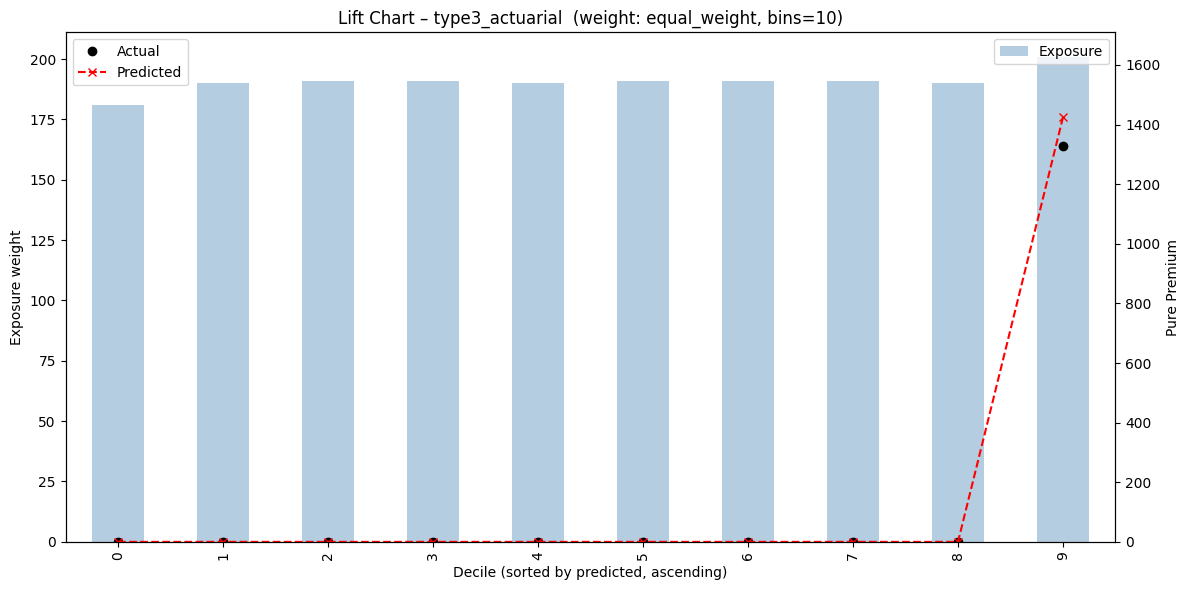

 decile  weight        act         pred
    1.0   181.0    0.00000 3.798723e-08
    2.0   190.0    0.00000 3.798723e-08
    3.0   191.0    0.00000 3.798723e-08
    4.0   191.0    0.00000 3.798723e-08
    5.0   190.0    0.00000 3.798723e-08
    6.0   191.0    0.00000 3.798723e-08
    7.0   191.0    0.00000 3.933311e-08
    8.0   191.0    0.00000 4.605806e-08
    9.0   190.0    0.00000 4.977392e-08
   10.0   201.0 1327.25919 1.424621e+03


In [11]:
from visualization import lift_chart, model_metrics, compare_lift_charts

# Individual lift charts for each encoding strategy
for r in all_results:
    lift_chart(r, test_df=test_raw, bins=10, print_table=True)

---
## 9 · Lift Chart Comparison – All 4 Strategies

  💾 Comparison lift chart saved: /Users/Mach/dev/aps/code/26CF_Dmod_v1/experiment_levels/results/lift_charts/comparison_lift.png


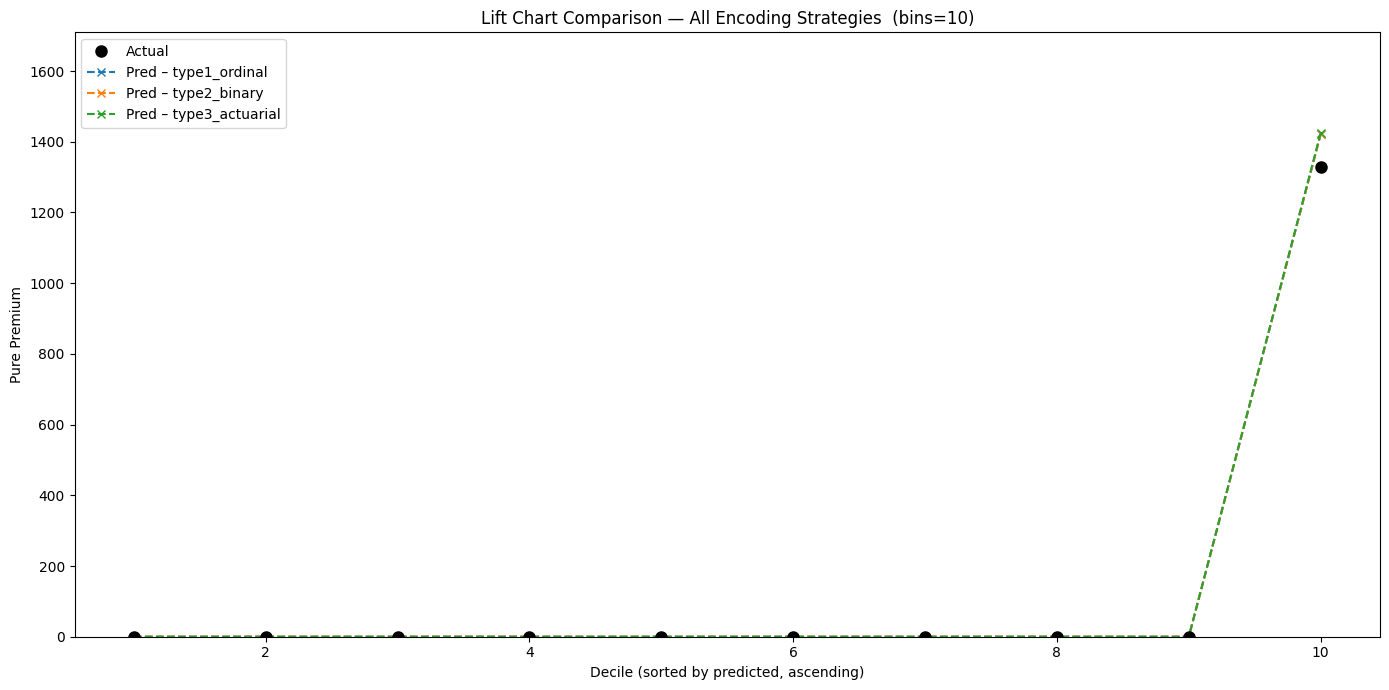


  ACTUARIAL METRICS COMPARISON
                 model_power  fit_quality         rmse
experiment_name                                       
type3_actuarial     1.862553     0.097669  1318.913473
type1_ordinal       1.860187     0.097919  1400.832119
type2_binary        1.859718     0.097968  1537.981713

  📄 Actuarial metrics saved: /Users/Mach/dev/aps/code/26CF_Dmod_v1/experiment_levels/results/actuarial_metrics_summary.csv


,model_power,fit_quality,rmse
experiment_name,,,
type3_actuarial,1.862553,0.097669,1318.913473
type1_ordinal,1.860187,0.097919,1400.832119
type2_binary,1.859718,0.097968,1537.981713


In [12]:
# Overlay all 4 predictions on a single lift chart + compute actuarial metrics
actuarial_summary = compare_lift_charts(all_results, test_df=test_raw, bins=10)

display(actuarial_summary)

---
## 10 · Actuarial Metrics – Per Experiment

In [13]:
# Detailed actuarial metrics (50-bin precision)
print('Actuarial Metrics (50-bin):')
print(f'{"Experiment":<22}  {"Model Power":>12}  {"Fit Quality":>12}  {"RMSE":>10}')
print('-' * 62)
for r in all_results:
    m = model_metrics(r, test_df=test_raw, bins=50)
    print(f"{r['experiment_name']:<22}  {m['model_power']:>12.4f}  {m['fit_quality']:>12.4f}  {r['metrics']['rmse']:>10.4f}")

Actuarial Metrics (50-bin):
Experiment               Model Power   Fit Quality        RMSE
--------------------------------------------------------------
type1_ordinal                 2.0206        0.0234   1400.8321
type2_binary                  2.0202        0.0234   1537.9817
type3_actuarial               2.0230        0.0233   1318.9135


---
## 11 · Pipeline summary

In [14]:
winner = summary_df["rmse"].idxmin()

print("╔══════════════════════════════════════════════════════════════╗")
print("║         XGBoost ENCODING BENCHMARK COMPLETE                  ║")
print(f"║  Mode          : {'DEBUG (10K rows)' if DEBUG else 'FULL DATA'}")
print(f"║  Target        : pp_bi")
print("╠══════════════════════════════════════════════════════════════╣")
for exp, row in summary_df.iterrows():
    flag = " ← 🏆 WINNER" if exp == winner else ""
    print(f"║  {exp:<20}  RMSE={row['rmse']:.4f}  R²={row['r2']:.4f}{flag}")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  Models saved  → models/pp_bi_type*/")
print(f"║  Summary CSV   → results/encoding_benchmark_summary.csv")
print("╚══════════════════════════════════════════════════════════════╝")
print()
print("Next: provide your lift chart / SHAP code to add model comparison visuals.")

╔══════════════════════════════════════════════════════════════╗
║         XGBoost ENCODING BENCHMARK COMPLETE                  ║
║  Mode          : DEBUG (10K rows)
║  Target        : pp_bi
╠══════════════════════════════════════════════════════════════╣
║  type3_actuarial       RMSE=1318.9135  R²=0.8074 ← 🏆 WINNER
║  type1_ordinal         RMSE=1400.8321  R²=0.7827
║  type2_binary          RMSE=1537.9817  R²=0.7381
╠══════════════════════════════════════════════════════════════╣
║  Models saved  → models/pp_bi_type*/
║  Summary CSV   → results/encoding_benchmark_summary.csv
╚══════════════════════════════════════════════════════════════╝

Next: provide your lift chart / SHAP code to add model comparison visuals.
